In [40]:
# import all necessary packages
import os

import json
import awkward as ak

import torch
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np

In [3]:
# define the config of the black box you want to look at
CONFIG_FILE = "test_config.json"

with open(CONFIG_FILE, "r") as f:
    config = json.load(f)

checkpoint_dir = config["options"]["checkpoint_dir"]

In [4]:
# function to load the black box data and labels
def load_blackbox(checkpoint_dir=checkpoint_dir):

    data_file = os.path.join(checkpoint_dir, "blackbox_data.parquet")
    labels_file = os.path.join(checkpoint_dir, "blackbox_labels.parquet")

    # load blackbox
    print("\nLoading blackbox...")
    if not os.path.exists(data_file):
        raise RuntimeError(f"No final blackbox found: {data_file}")
    
    data = ak.from_parquet(data_file)
    print(f"Loaded {len(data)} events from {data_file}")

    # load labels
    print("\nLoading labels...")
    if not os.path.exists(labels_file):
        raise RuntimeError(f"No final blackbox found: {labels_file}")
    
    labels = ak.from_parquet(labels_file)
    print(f"Loaded {len(labels)} labels from {labels_file}")


    return data, labels

In [48]:
# load the data and labels
data, labels = load_blackbox()


Loading blackbox...
Loaded 52044887 events from test_blackbox_checkpoint/blackbox_data.parquet

Loading labels...
Loaded 52044887 labels from test_blackbox_checkpoint/blackbox_labels.parquet


In [6]:
# have a look at the data output:
# the variables are saved per event and are associated with more general fields like lep, jet, ...
data

<Array [{lep: {...}, jet: {...}, ...}, ...] type='52044887 * {lep: {pt: var...'>

In [7]:
# look at the lep field
data.lep

<Array [{pt: [], eta: [], phi: [], ...}, ...] type='52044887 * {pt: var * f...'>

In [8]:
# the labels are saved in an array, 1 meaning signal and 0 background
labels

<Array [0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0] type='52044887 * int64'>

In [49]:
# event selection criteria
mask_exactly2leptons = data.lep.n == 2
# define mask with filter criterium
data_2lep = data[mask_exactly2leptons]

In [50]:
print("Number of events in the original signal dataset:", len(data))
print("Number of events with at least 2 leptons:", len(data_2lep))

Number of events in the original signal dataset: 52044887
Number of events with at least 2 leptons: 18420141


In [51]:
# Convert the lepton kinematic variables of the zeroth lepton in each event to PyTorch tensors.
# The [:,0] indexing selects the zeroth lepton from each event.
# We also define the datatype for each array - this makes things faster

lepton0_pt_tensor  = torch.tensor(data_2lep.lep.pt[:,0] , dtype=torch.float32)
lepton0_eta_tensor = torch.tensor(data_2lep.lep.eta[:,0], dtype=torch.float32)
lepton0_phi_tensor = torch.tensor(data_2lep.lep.phi[:,0], dtype=torch.float32)
lepton0_e_tensor   = torch.tensor(data_2lep.lep.e[:,0]  , dtype=torch.float32)

lepton1_pt_tensor  = torch.tensor(data_2lep.lep.pt[:,1] , dtype=torch.float32)
lepton1_eta_tensor = torch.tensor(data_2lep.lep.eta[:,1], dtype=torch.float32)
lepton1_phi_tensor = torch.tensor(data_2lep.lep.phi[:,1], dtype=torch.float32)
lepton1_e_tensor   = torch.tensor(data_2lep.lep.e[:,1]  , dtype=torch.float32)

In [74]:
# stack the tensors into a single tensor
input_tensor = torch.stack([lepton0_pt_tensor,
             lepton0_eta_tensor,
             lepton0_phi_tensor,
             lepton0_e_tensor,
             lepton1_pt_tensor,
             lepton1_eta_tensor,
             lepton1_phi_tensor,
             lepton1_e_tensor,
             ], dim=1)

In [75]:
labels_2lep = labels[mask_exactly2leptons]

signal_idx = np.where(labels_2lep == 1)[0]
background_idx = np.where(labels_2lep == 0)[0]

# Anzahl der Events der kleineren Klasse
n = min(len(signal_idx), len(background_idx))

# Zufällige Auswahl
rng = np.random.default_rng(4)

signal_idx = rng.choice(
    signal_idx,
    size=n,
    replace=False
)

background_idx = rng.choice(
    background_idx,
    size=n,
    replace=False
)

# Zusammenführen
selected_idx = np.concatenate([
    signal_idx,
    background_idx
])

# Durchmischen
rng.shuffle(selected_idx)

# ==========================================
# Tensor und Labels reduzieren
# ==========================================

input_tensor = input_tensor[selected_idx]
labels_2lep = labels_2lep[selected_idx]
print(len(input_tensor), len(labels_2lep))

27584 27584


In [76]:
# define the target

target_tensor = torch.tensor(labels_2lep, dtype=torch.float32)

In [77]:
# train test split
X_train, X_test = train_test_split(input_tensor, test_size=0.2, random_state=4)
Y_train, Y_test = train_test_split(target_tensor, test_size=0.2, random_state=4)

In [78]:
# Compute the mean and standard deviation
mean = X_train.mean(dim=0, keepdim=True)
std = X_train.std(dim=0, keepdim=True)

# Transform step: Apply the standardization formula
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

In [79]:
device = "cpu"
X_train_scaled = X_train_scaled.to(device)
X_test_scaled = X_test_scaled.to(device)

Y_train = Y_train.to(device)
Y_test = Y_test.to(device)

In [93]:
# =========== PyTorch Approach ============ #
model = nn.Sequential(
    nn.Linear(8, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid(),
)

# Our model should live on the same device as our tensors
model = model.to(device)

In [94]:
# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [95]:
train_losses = []
test_losses = []

N_epochs = 300

for epoch in range(N_epochs):

    model.train()
    # tell the optimizer to begin an optimization step
    optimizer.zero_grad()

    # forward pass
    # use the model as a prediction function: features → predictions
    predictions = model(X_train_scaled)

    # compute the loss between these predictions and the intended targets
    loss = criterion(predictions.squeeze(), Y_train)

    # Compute the gradients of the loss wrt the trainable parameters
    loss.backward()

    # Update the model parameters based on the gradients
    optimizer.step()

    # Purely for monitoring and visualisation: keeping track of the losses
    train_losses.append(loss.item())


    # validation
    model.eval()

    with torch.no_grad():
        test_predictions = model(X_test_scaled)
        test_loss = criterion(test_predictions.squeeze(), Y_test)

    test_losses.append(test_loss.item())

    print(
        f'Epoch [{epoch + 1}/{N_epochs}], '
        f'Train Loss: {loss.item():.4f}, '
        f'Test Loss: {test_loss.item():.4f}')

Epoch [1/300], Train Loss: 0.6987, Test Loss: 0.6726
Epoch [2/300], Train Loss: 0.6715, Test Loss: 0.6464
Epoch [3/300], Train Loss: 0.6448, Test Loss: 0.6207
Epoch [4/300], Train Loss: 0.6186, Test Loss: 0.5952
Epoch [5/300], Train Loss: 0.5930, Test Loss: 0.5699
Epoch [6/300], Train Loss: 0.5675, Test Loss: 0.5446
Epoch [7/300], Train Loss: 0.5421, Test Loss: 0.5194
Epoch [8/300], Train Loss: 0.5166, Test Loss: 0.4942
Epoch [9/300], Train Loss: 0.4911, Test Loss: 0.4690
Epoch [10/300], Train Loss: 0.4657, Test Loss: 0.4439
Epoch [11/300], Train Loss: 0.4403, Test Loss: 0.4191
Epoch [12/300], Train Loss: 0.4150, Test Loss: 0.3945
Epoch [13/300], Train Loss: 0.3901, Test Loss: 0.3705
Epoch [14/300], Train Loss: 0.3657, Test Loss: 0.3472
Epoch [15/300], Train Loss: 0.3420, Test Loss: 0.3248
Epoch [16/300], Train Loss: 0.3193, Test Loss: 0.3036
Epoch [17/300], Train Loss: 0.2977, Test Loss: 0.2837
Epoch [18/300], Train Loss: 0.2774, Test Loss: 0.2652
Epoch [19/300], Train Loss: 0.2586, T

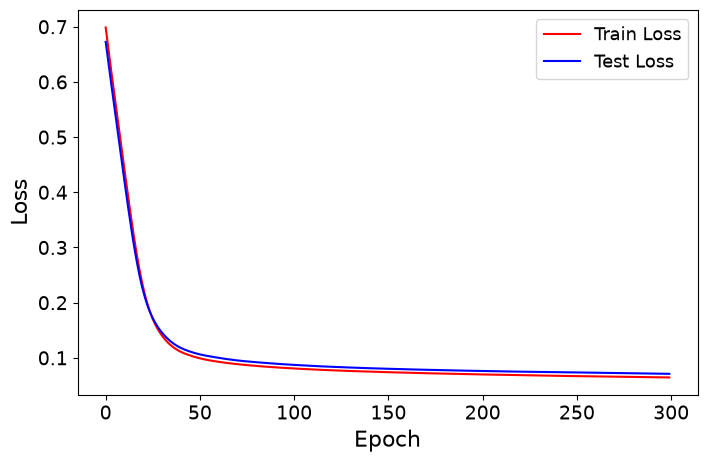

In [110]:
# plot loss function for training and validation sets
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', color='red')
plt.plot(test_losses, label='Test Loss', color='blue')

plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.tick_params(axis="both", which="major", labelsize=14)
plt.legend(fontsize=13)
plt.savefig("loss.pdf")
plt.show()

tensor([[0.0476],
        [0.9999],
        [0.9970],
        ...,
        [1.0000],
        [1.0000],
        [0.0131]])
0.9782490483958673


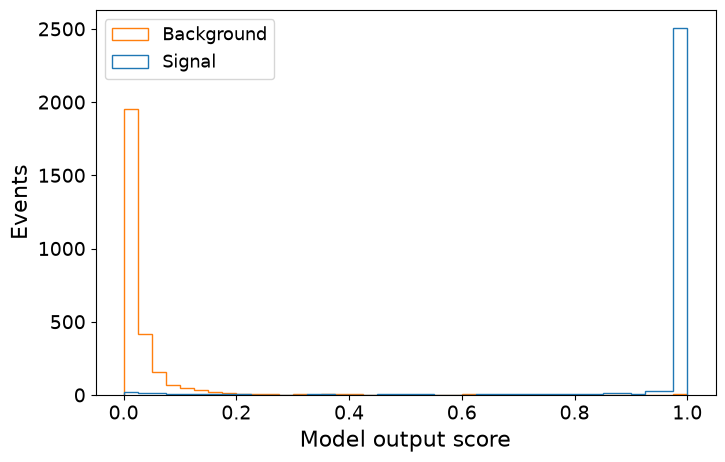

In [102]:
# Model evaluation is simple: call the model
# We detach the array
y_pred = model(X_test_scaled).detach()
print(y_pred)

# Plot the scores
#plt.hist(y_pred,bins=40)
#plt.xlabel('Model output score')
#plt.ylabel('Events')

threshold = 0.5
y_pred_labels = (y_pred >= threshold).float()

accuracy = accuracy_score(Y_test, y_pred_labels)
print(accuracy)

# Plotting the model outputs for signal and background separately
signal_scores = y_pred[Y_test == 1].flatten()
background_scores = y_pred[Y_test == 0].flatten()
plt.figure(figsize=(8, 5))
plt.hist([signal_scores,background_scores], bins=40, histtype='step', label=['Signal','Background'])
plt.legend(fontsize=13)
plt.xlabel('Model output score', fontsize=16)
plt.ylabel('Events', fontsize=16)
plt.tick_params(axis="both", which="major", labelsize=14)
plt.savefig("pytorch.pdf", bbox_inches="tight")
plt.show()